# named op or generic op
BMM, bsx197x1024, bsx1024x197 => MM, bs*197x1024, 1024xbs*197

In [1]:
import numpy as np
import torch
import torch.utils.benchmark as benchmark
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import wraps
from time import perf_counter
from collections import namedtuple

from ragdoll.utils import *
from ragdoll.visualisation import *
from ragdoll.benchmark import *
import ragdoll

/tmp/ipykernel_1295076/3465895806.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:

gen_results = []
gen_throughput = []
bs_list = [32, 32, 32, 32, 32, 32, 32]
hi_list = [224, 56, 28, 14, 56, 28, 14]
ci_list = [3, 64, 128, 256, 128, 256, 512]
ho_list = [112, 56, 28, 14, 56, 28, 14]
co_list = [64, 128, 256, 512, 32, 64, 128]
k_list = [7, 1, 1, 1, 3, 3, 3]
dilation_list = [1, 1, 1, 1, 1, 1, 1]
pad_list = [3, 0, 0, 0, 1, 1, 1]
stride_list = [2, 1, 1, 1, 1, 1, 1]
for idx in range(len(k_list)):
    B = bs_list[idx]
    HI = hi_list[idx]
    CI = ci_list[idx]
    HO = ho_list[idx]
    CO = co_list[idx]
    K = k_list[idx]
    D = dilation_list[idx]
    P = pad_list[idx]
    S = stride_list[idx]
    print("benchmarking CONV #{}".format(idx))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{B}x{HI}x{HI}x{CI}xf32>, %arg1: tensor<{CO}x{K}x{K}x{CI}xf32>) -> tensor<{B}x{HO}x{HO}x{CO}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{CO}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{CO}xf32>) -> tensor<{CO}xf32>
        %2 = tosa.conv2d %arg0, %arg1, %1 BRKLEFTdilation = array<i64: {D}, {D}>, pad = array<i64: {P}, {P}, {P}, {P}>, stride = array<i64: {S}, {S}>BRKRIGHT : (tensor<{B}x{HI}x{HI}x{CI}xf32>, tensor<{CO}x{K}x{K}x{CI}xf32>, tensor<{CO}xf32>) -> tensor<{B}x{HO}x{HO}x{CO}xf32>
        return %2 : tensor<{B}x{HO}x{HO}x{CO}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !ragdoll-opt {mlir_file_name} --linalg-generalize-named-ops > {mlir_file_name}.generic
    !iree-compile {mlir_file_name}.generic \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_70
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(B, HI, HI, CI), (CO, K, K, CI)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    gen_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*B*CO*CI*HO*HO*K*K*1000000000
    gen_throughput.append(GFLOPS/np.mean(ragdoll_bench))
gen_data = pd.DataFrame([list(range(16, 1000, 16)), gen_results])
gen_data.to_csv('op_spec_generic_gpu.csv')

benchmarking CONV #0


/root/AlbertResearches/researches/Ragdoll/ragdoll/benchmark/op_benchmark.py:192: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


benchmarking CONV #1
benchmarking CONV #2
benchmarking CONV #3
benchmarking CONV #4
benchmarking CONV #5
benchmarking CONV #6


In [3]:

mm_results = []
mm_throughput = []
bs_list = [32, 32, 32, 32, 32, 32, 32]
hi_list = [224, 56, 28, 14, 56, 28, 14]
ci_list = [3, 64, 128, 256, 128, 256, 512]
ho_list = [112, 56, 28, 14, 56, 28, 14]
co_list = [64, 128, 256, 512, 32, 64, 128]
k_list = [7, 1, 1, 1, 3, 3, 3]
dilation_list = [1, 1, 1, 1, 1, 1, 1]
pad_list = [3, 0, 0, 0, 1, 1, 1]
stride_list = [2, 1, 1, 1, 1, 1, 1]
for idx in range(len(k_list)):
    B = bs_list[idx]
    HI = hi_list[idx]
    CI = ci_list[idx]
    HO = ho_list[idx]
    CO = co_list[idx]
    K = k_list[idx]
    D = dilation_list[idx]
    P = pad_list[idx]
    S = stride_list[idx]
    print("benchmarking CONV #{}".format(idx))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{B}x{HI}x{HI}x{CI}xf32>, %arg1: tensor<{CO}x{K}x{K}x{CI}xf32>) -> tensor<{B}x{HO}x{HO}x{CO}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{CO}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{CO}xf32>) -> tensor<{CO}xf32>
        %2 = tosa.conv2d %arg0, %arg1, %1 BRKLEFTdilation = array<i64: {D}, {D}>, pad = array<i64: {P}, {P}, {P}, {P}>, stride = array<i64: {S}, {S}>BRKRIGHT : (tensor<{B}x{HI}x{HI}x{CI}xf32>, tensor<{CO}x{K}x{K}x{CI}xf32>, tensor<{CO}xf32>) -> tensor<{B}x{HO}x{HO}x{CO}xf32>
        return %2 : tensor<{B}x{HO}x{HO}x{CO}xf32>
      BRKRIGHT
    BRKRIGHT"""
    
    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb2 \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_70
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb2",
        [(B, HI, HI, CI), (CO, K, K, CI)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    mm_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*B*CO*CI*HO*HO*K*K*1000000000
    mm_throughput.append(GFLOPS/np.mean(ragdoll_bench))
mm_data = pd.DataFrame([list(range(16, 1000, 16)), mm_results])
mm_data.to_csv('op_spec_named_gpu.csv')

benchmarking CONV #0
benchmarking CONV #1
benchmarking CONV #2
benchmarking CONV #3
benchmarking CONV #4
benchmarking CONV #5
benchmarking CONV #6


/tmp/ipykernel_1295076/3063586469.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)
/tmp/ipykernel_1295076/3063586469.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  right.set_xticklabels(right.get_xticklabels(), rotation=30)


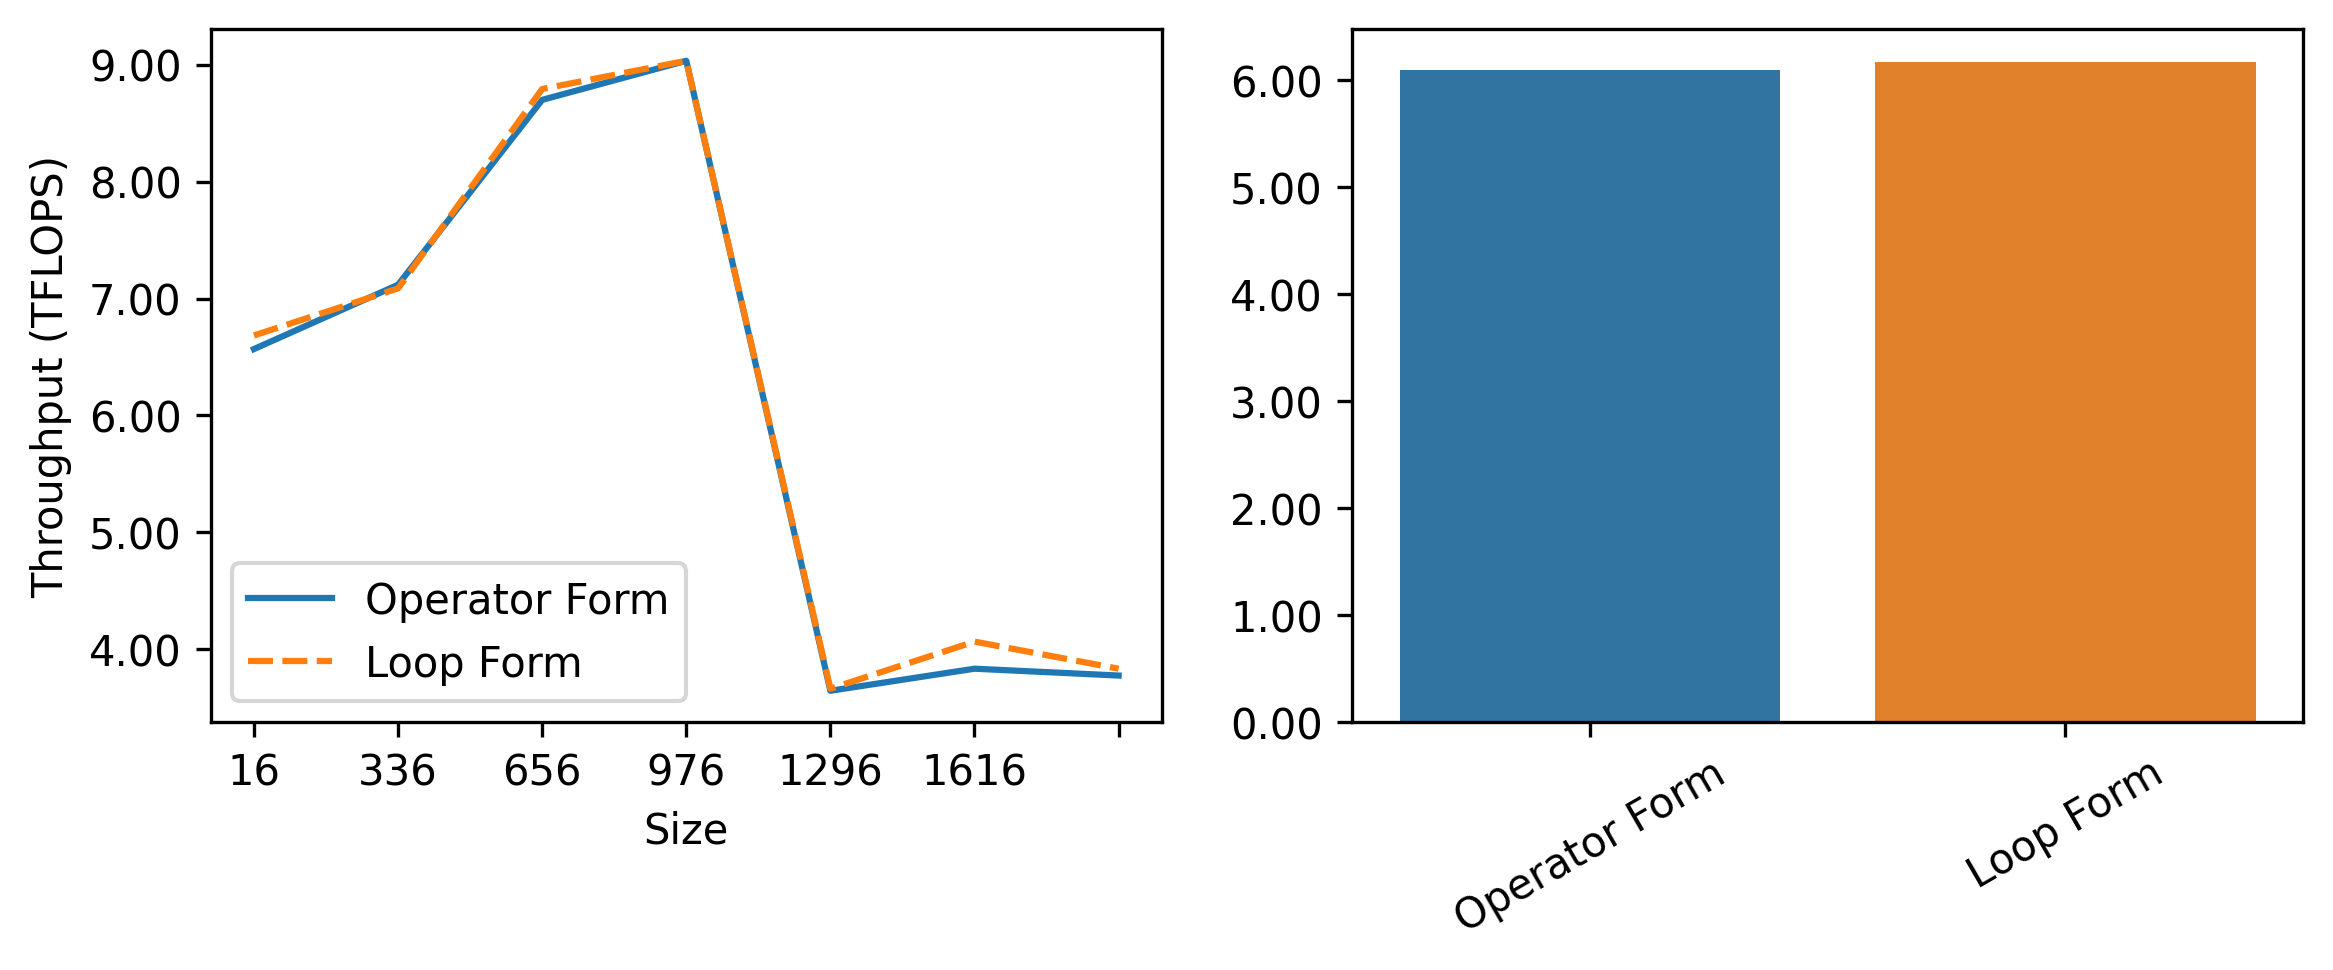

/tmp/ipykernel_1295076/3063586469.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)
/tmp/ipykernel_1295076/3063586469.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  right.set_xticklabels(right.get_xticklabels(), rotation=30)


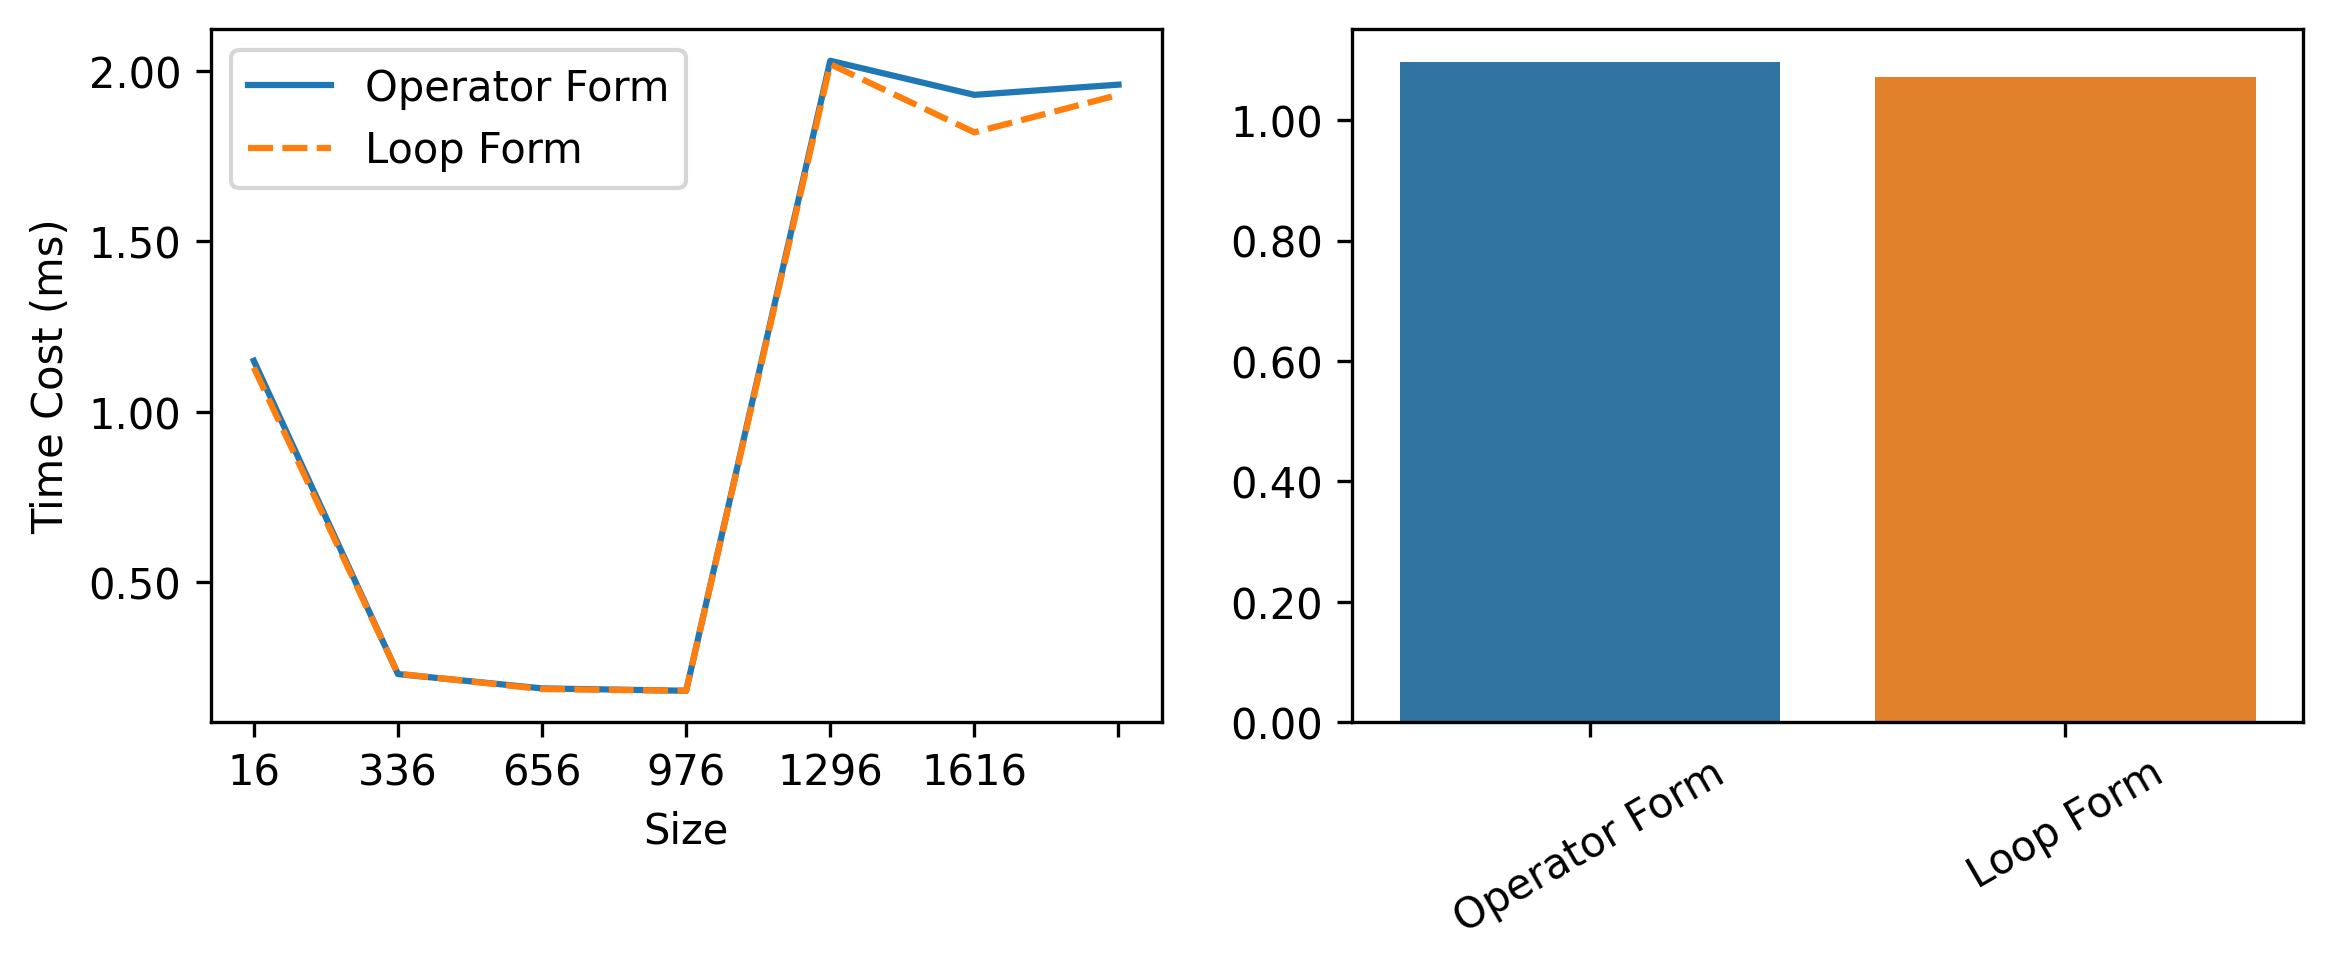

In [4]:
# do throughput
names = ['Operator Form', 'Loop Form']
results = [mm_results, gen_results]
throughputs = [mm_throughput, gen_throughput]

from matplotlib.ticker import FuncFormatter
line_data = pd.DataFrame(dict(zip(names, [res for res in throughputs])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in throughputs])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Throughput (TFLOPS)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()

line_data = pd.DataFrame(dict(zip(names, [res for res in results])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))
fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Time Cost (ms)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()